# Particle filter practice

To discover the PF analysis machinery.

You are monitoring air temperature in Grenoble, with some model and a thermometer installed on the top of your roof. Your 6-member ensemble simulation provides temperature of 8, 8.7, 9.3, 9.5, 9.8, 10.2 . And your thermometer provides an observation of 9.25. You estimate the standard deviation of the thermometer uncertainty at 0.25. This incertainty is assumed Gaussian.

1. Compute the weights of the ensemble.
2. Resample.

Feel free to code for your calculations, but you don't have to.

In [1]:
Ne=6
x0=[8, 8.7, 9.3, 9.5, 9.8, 10.2]
sigma_obs=0.25
y0=9.25


In [2]:
# 1.Weighting
import numpy as np
w = [np.exp(-1/(2*sigma_obs**2)*(y0-x0[i])**2) for i in range(Ne)]
w = w / np.sum(w)
print(w)

[2.11104972e-06 5.03717270e-02 5.55256431e-01 3.43583458e-01
 5.03717270e-02 4.14546571e-04]


In [3]:
# 2.Resampling
import random
delta = 1/Ne
cumulated_weights = np.cumsum(w)
print(cumulated_weights)
for i in range(10):
    selected_particles = list()
    u = random.uniform(0, delta)
    while u <= 1:
        #print(u)
        selected_particles.append(np.searchsorted(cumulated_weights, u)+1)
        u += delta
    print(selected_particles)

[2.11104972e-06 5.03738380e-02 6.05630269e-01 9.49213726e-01
 9.99585453e-01 1.00000000e+00]
[3, 3, 3, 4, 4, 4]
[2, 3, 3, 3, 4, 4]
[3, 3, 3, 3, 4, 4]
[3, 3, 3, 4, 4, 5]
[2, 3, 3, 3, 4, 4]
[3, 3, 3, 3, 4, 4]
[2, 3, 3, 3, 4, 4]
[2, 3, 3, 3, 4, 4]
[3, 3, 3, 4, 4, 5]
[3, 3, 3, 4, 4, 5]


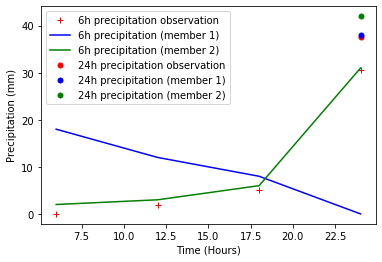

In [4]:
import numpy as np
import matplotlib.pyplot as plt
Ne=2
sigma_obs=2
t=range(6, 30, 6)
x=np.array([[18, 2], [12, 3], [8, 6], [0, 31]]) # 6-hour precipitation guess
X=np.array([np.sum(x[:, 0]), np.sum(x[:, 1])]) # 24-hour precipitation guess
y=[0, 2, 5, 30.5] # 6-hour precipitation observation
Y=np.sum(y) # 24-hour precipitation observation
plt.plot(t, y, linestyle='', marker='+', label='6h precipitation observation', color='red')
plt.plot(t, x[:,0], label='6h precipitation (member 1)', color='blue')
plt.plot(t, x[:,1], label='6h precipitation (member 2)', color='green')
plt.xlabel('Time (Hours)')
plt.ylabel('Precipitation (mm)')
plt.plot(24, Y, '.', label='24h precipitation observation', linestyle='', color='red', markersize=10)
plt.plot(24, X[0], '.', label='24h precipitation (member 1)', color='blue', markersize=10)
plt.plot(24, X[1], '.', label='24h precipitation (member 2)', color='green', markersize=10)
plt.legend()


In [5]:
def Gaussian_PDF(x, mu, sigma):
    # = [np.exp(-1/(2*sigma_obs**2)*(Y-X[i])**2) for i in range(Ne)]
    return 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-(x-mu)**2/(2*sigma**2))


In [6]:
# 1.1 Weighting with 6-hour precipitatinon (Gaussian distribution)
# WARNING : in a real situation this may lead to "the curse of dimensionality"
w = [np.sum(Gaussian_PDF(x[:, n], y, sigma_obs)) for n in range(Ne)]
w = w / np.sum(w)
print('Weights [P1, P2] = ',w)

Weights [P1, P2] =  [0.08857286 0.91142714]


In [7]:
# 1.2 Weighting with 24-hour precipitatinon (Gaussian distribution)
w = Gaussian_PDF(X, Y, sigma_obs)
w = w / np.sum(w)
print('Weights [P1, P2] = ',w)

Weights [P1, P2] =  [0.92414182 0.07585818]


In [16]:
def gamma_PDF(x, mu=3, sigma=1):
    import math
    if x > 0:
        if mu == 0:
            k = 1 # TODO : Arbitrary value to define preoperly xhen the observed precipitation is 0
                          # Maybe something dependent on neighboring observations ?
            theta = 2 # TODO : Arbitrary value to define preoperly xhen the observed precipitation is 0
                          # Maybe something dependent on neighboring observations ? 
        else:
            k = mu**2 / sigma**2
            theta = sigma**2 / mu
        #return x**(k-1)*np.exp(-x/theta)/(theta**k*math.factorial(k-1))
        # continuous case : G(k) is en integral, but not important since it is a constant and the weights are then normalised
        return x**(k-1)*np.exp(-x/theta)/(theta**k*math.gamma(k))
    else:
        return ValueError('Gamma function only defined for x > 0')

In [68]:
# Definition of gamma distribution
def gamma_shape_PDF(x, k=3, theta=1):
    import math  
    if isinstance(x, np.ndarray):
        gamma = np.array(list(map(lambda t: t**(k-1)*np.exp(-t/theta)/(theta**k*math.gamma(k)) if t > 0 else None, x))) 
    else:
        gamma = x**(k-1)*np.exp(-x/theta)/(theta**k*math.gamma(k)) if x > 0 else None
    ax = plt.gca()
    color = next(ax._get_lines.prop_cycler)['color']
    # Plot over a smaller range for better lisibility
    if k<10:
        ymax = 5*theta*k
    else:
        ymax = (k*theta)*(1+theta**2)
    print(k, theta, ymax)
    ax.plot(y[y<ymax], gamma[y<ymax], linestyle=':', color=color)
    ax.plot(y[(y>0) & (y<ymax)], gamma[(y>0) & (y<ymax)], 
             label=f'GAMMA (k={k:0.2}, theta={theta})', color=color)
    
    return gamma


1.0 1 5.0
1.0 2 10.0
1.0 3 15.0
1.0 4 20.0
1.0 5 25.0


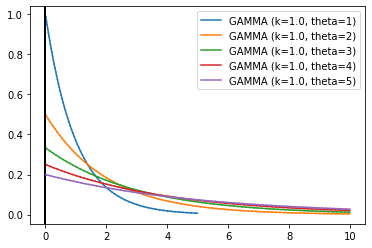

In [74]:
# I - Loi gamma
# Parameters :
k     = 1.0
theta = 1.0

y = np.arange(0, 10, dy)


for theta in range(1, 6):
    dy = 0.01
    plt.axvline(x=0, color='k', linestyle='-')
    plt.axvline(x=delta, color='k', linestyle='--')
    gamma = gamma_shape_PDF(y, k=k, theta=theta)
plt.legend()



In [10]:
# Definition of SCGD
def SCGD_shape_PDF(x, k=1, theta=1, delta=0, continu=False, plot=True):
    if not (isinstance(x, (list, np.ndarray))):
        x = np.array([x])
    #if delta > 0:
    #    # WARNING : dans Schuerer and Hammil 2015 and Nusu 2019 delat est définit comme > 0, ce qui entraine un 
    #    # décallage vers la droite plutot que vers la gauche...
    #    raise ValueError('Error : delta parameter must be <= 0')
           
    dy = 0.01
        
    if continu:
        # On commence par calculer la fonction sur un intervale suffisant pour que l'aire sous la courbe soit ~1
        # Cela permet de définir le shift 'delta' à appliquer pour que la probabilté résiduelle en 0
        # soit "continue" avec le reste de la courbe
        # Dans ce cas on n'utilise pas le 'delta' passé en argument mais on le calcule
        y = np.arange(0, 10*theta**2*k, dy) # WARNING : 'y' doit ABSOLUMENT couvrir toute la distribution 
                                        # de gamma sinon la probabilité en 0 est artificiellement surestimée !
        gamma = np.array(list(map(
            lambda t: gamma_shape_PDF(t/theta, k=k, theta=theta) if t>0 else 0, y)))
        integral = 0
        g = gamma_shape_PDF(dy, k=k, theta=theta)
        n = 0
        while not (integral-g < 0.01 and integral-g > -0.01) and n<100000 :
            n = n + 1
            g = gamma_shape_PDF(n*dy, k=k, theta=theta)
            integral = integral + g*dy/theta
        scgd0 = integral
        delta = -n*dy*theta
        print('delta=',delta)
        #print(f'{n} intérations')
        #print('delta=',delta)

        gamma = np.array(list(map(
            lambda t: gamma_shape_PDF((t-delta)/theta, k=k, theta=theta) if t > delta else 0, y)))
    else:
        # On utilise directement le delta passé en argument
        # Méthode beaucoup moins couteuse (on évite le calcul itératif de l'aire sous la courbe)
        # mais donnant une distribution discontinue en 0 et potentiellement accoreder trop / trop peu de 
        # poids aux precipitations nulles
        y = np.arange(delta, 2*theta*(k-1)+k*theta**2, dy) # WARNING : 'y' doit ABSOLUMENT couvrir toute la distribution 
                                        # de gamma sinon la probabilité en 0 est artificiellement surestimée !
        gamma = np.array(list(map(
            lambda t: gamma_shape_PDF(t-delta, k=k, theta=theta) if t > delta else 0, y)))
        scgd0 = 1 - sum(gamma[y>0]*dy) # Calcul de la probabilité résiduelle en 0

    if plot:
        ax = plt.gca()
        color = next(ax._get_lines.prop_cycler)['color']
        # Plot over a smaller range for better lisibility
        if k<10:
            ymax = theta*(k-1)+k*theta**2
        else:
            ymax = (k*theta)*(1+theta**2)
        ax.plot(y[y<ymax], gamma[y<ymax], linestyle=':', color=color)
        ax.plot(y[(y>0) & (y<ymax)], gamma[(y>0) & (y<ymax)], 
                 label=f'SCGD (k={k:0.2}, theta={theta}, delta={delta:0.2})', color=color)
        if scgd0 > 0.0001:
            ax.plot(0, scgd0, marker='.', markersize=20, markeredgecolor=color, markeredgewidth=2,
                     color='none', markerfacecolor='lightgrey', label=f'P(0)={scgd0:0.3}')
            ax.fill_between(x=y, y1=gamma, where=(delta < y)&(y < 0), color='lightgrey')
        #ax.bar(0, scgd0, width=0.2, align='edge', color=color)
        #ax.bar(0, scgd0, width=0.2, color=color)

    return np.array(list(map(lambda t: gamma_shape_PDF(t-delta, k=k, theta=theta) if t > 0 
                    else scgd0 if t == 0 else 0, x)))



In [11]:
# Definition of SCGD
def SCGD_shape_PDF(x, k=1, theta=1, delta=0, continu=False, plot=True):
    if not (isinstance(x, (list, np.ndarray))):
        x = np.array([x])
    #if delta > 0:
    #    # WARNING : dans Schuerer and Hammil 2015 and Nusu 2019 delat est définit comme > 0, ce qui entraine un 
    #    # décallage vers la droite plutot que vers la gauche...
    #    raise ValueError('Error : delta parameter must be <= 0')
           
    dy = 0.01
    # On utilise directement le delta passé en argument
    # Méthode beaucoup moins couteuse (on évite le calcul itératif de l'aire sous la courbe)
    # mais donnant une distribution discontinue en 0 et potentiellement accoreder trop / trop peu de 
    # poids aux precipitations nulles
    y = np.arange(theta*(k-1)-k*theta**2, theta*(k-1)+k*theta**2, dy) # WARNING : 'y' doit ABSOLUMENT couvrir toute la distribution 
                                    # de gamma sinon la probabilité en 0 est artificiellement surestimée !
    gamma = np.array(list(map(
        lambda t: gamma_shape_PDF(t-delta, k=k, theta=theta) if t > delta else 0, y)))
    scgd0 = 1 - sum(gamma[y>0]*dy) # Calcul de la probabilité résiduelle en 0
    import scipy
    print('DBUG')
    print(scgd0)
    import scipy.special as sc
    
    print(sc.gammainc(k, -delta/theta)/sc.gamma(k))

    if plot:
        ax = plt.gca()
        color = next(ax._get_lines.prop_cycler)['color']
        # Plot over a smaller range for better lisibility
        ymin = theta*(k-1)-k*theta**2
        ymax = theta*(k-1)+1.5*k*theta**2
        ax.plot(y[y<ymax], gamma[y<ymax], linestyle=':', color=color)
        ax.plot(y[(y>0) & (y<ymax)], gamma[(y>0) & (y<ymax)], 
                 label=f'SCGD (k={k:0.2}, theta={theta}, delta={delta:0.2})', color=color)
        if scgd0 > 0.0001:
            ax.plot(0, scgd0, marker='.', markersize=20, markeredgecolor=color, markeredgewidth=2,
                     color='none', markerfacecolor='lightgrey', label=f'P(0)={scgd0:0.3}')
            ax.fill_between(x=y, y1=gamma, where=(delta < y)&(y < 0), color='lightgrey')
        #ax.bar(0, scgd0, width=0.2, align='edge', color=color)
        #ax.bar(0, scgd0, width=0.2, color=color)

    return np.array(list(map(lambda t: gamma_shape_PDF(t-delta, k=k, theta=theta) if t > 0 
                    else scgd0 if t == 0 else 0, x)))

DBUG
0.008688395807858185
1.2091653390309336e-06
DBUG
0.6829511307780844
0.6321205588285577


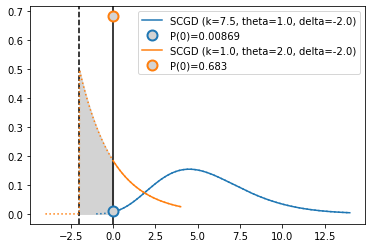

In [12]:
# I - Continuité en 0
# Parameters :
k     = 7.5
theta = 1.0
delta = -2.0

dy = 0.01
y = np.arange(0, 10, dy)
plt.axvline(x=0, color='k', linestyle='-')
plt.axvline(x=delta, color='k', linestyle='--')
scgd_gamma = SCGD_shape_PDF(y, k=k, theta=theta, delta=delta, continu=False)

k     = 1.0
theta = 2.0
scgd_gamma = SCGD_shape_PDF(y, k=k, theta=theta, delta=delta)
plt.legend()

1.5518331758555188
1.8121418641597227
DBUG
0.013044441791307815
nan


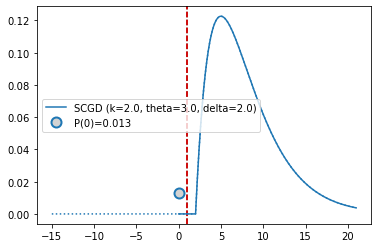

In [13]:
# I.2 Continuity of the SCGD

theta = 3
dy = 0.01
Y = 5 # Observation value
delta0 = 1 # Control default shift in the case of an observation of 0mm 
# ==> to choose according to neigboring observations ? 
delta = -1/(Y**2+delta0)
delta=0.
y = np.arange(0, 2*Y, dy)
#gamma = gamma_shape_PDF(y, k=k, theta=theta)
#plt.plot(y, gamma)
#plt.axvline(x=theta*(k-1), color='k', linestyle='--')
#y = np.arange(Y-10*theta**2, Y+10*theta**2, dy)
#plt.axvline(x=Y, color='k', linestyle='--')
#plt.axvline(x=delta, color='red', linestyle='--')
#plt.axvline(x=theta**2*(k-1)+delta, color='k', linestyle='--')
#k = (Y-delta)/theta**2+1
#scgd_gamma = SCGD_shape_PDF(y, k=k, theta=theta, delta=delta)

#for theta in [1,2,3,4]:
#    # When rr observation is 0mm, the shift is mandatory
#    # TODO : shift=0 for Y>threshold and maximum (?) when all neighboring observations ar 0 ?
#    # <==> shift must be a decreasing continuous function of the observation value Y
#    # TODO : the case Y=0 is specific and is still to be defined
#    k = (Y-delta)/theta**2+1
#    #print(SCGD_shape_PDF(0, k=k, theta=theta, delta=delta))
#    scgd_gamma = SCGD_shape_PDF(y, k=k, theta=theta, delta=delta)
##    plt.plot(y, scgd_gamma)
bias = -2.316
Y = 1
mu = Y # + bias ?
sigma = np.sqrt(5.096)
k = (2*sigma**2+mu**2+np.sqrt((mu**2*(4*sigma**2+mu**2))))/(2*sigma**2) # condition : k > 1
theta = mu / (k-1)
plt.axvline(x=Y, color='k', linestyle='--')
plt.axvline(x=theta*(k-1), color='red', linestyle='--')
print(k)
print(theta)

scgd_gamma = SCGD_shape_PDF(y, k=2., theta=3., delta=2.)
plt.legend()


Ensemble members :  [37 41 35 28 45 39]
Observation :  37
DBUG
6.803240393260523e-08
0.0


ValueError: Precision not allowed in integer format specifier

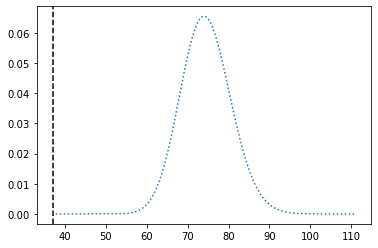

In [14]:
# I.3 Conditionnal SCGD for a given precipitation observation (>0)
theta = 3
delta = 0
X = np.array([37, 41, 35, 28, 45, 39]) # Ensemble forecast
Y = 37 # Observation
print('Ensemble members : ', X)
print('Observation : ', Y)
plt.axvline(x=Y, color='k', linestyle='--')
for theta in [0.5, 1, 2]:
    k = (Y-delta)/theta**2+1
    w = SCGD_shape_PDF(X, k=k, theta=theta, delta=delta)
    w = w / np.sum(w)
    print(f'Weights for theta={theta}:', w)
plt.legend()

In [ ]:
#1.4 Conditionnal SCGD for a given precipitation observation (=0)
X = np.array([0, 0, 0, 1, 5, 0, 0, 3, 0, 2, 0, 8, 10, 0]) # Ensemble forecast
Y = 0 # Observation
delta0 = 1 # Control default shift in the case of an observation of 0mm 
# ==> to choose according to neigboring observations ? 
delta = -1/(Y**2+delta0)
print('Ensemble members : ', X)
print('Observation : ', Y)
print('delta = ', delta)
plt.axvline(x=Y, color='k', linestyle='--')
if Y == 0:
    k = 1.0
    theta = 1.0
    print('theta=',theta)
    w = SCGD_shape_PDF(X, k=k, theta=theta, delta=delta)
    w = w / np.sum(w)
    print(f'Weights for theta={theta}:', w)
else:
    theta = 3
    for theta in [0.5, 1, 2, 4]:
        k = (Y-delta)/theta**2+1
        w = SCGD_shape_PDF(X, k=k, theta=theta, delta=delta)
        w = w / np.sum(w)
        print(f'Weights for theta={theta}:', w)
plt.legend()

In [ ]:
# II.1 Weighting 24-hour precipitation (Censored Shifted Gamma Distribution)
theta = 2
delta = 0
#X = np.array([37, 41, 35, 28, 45, 39]) # Ensemble forecast
Y = 37 # Observation
Ne = 20 # Ensemble size
a = Y/2
b = 2*Y
# Members are uniformly distributed in the intervale [a,b]
X = np.random.randint(a, b, size=Ne)

dt=0.1
t = np.arange(0, 100, dt)
xpdf = [1/(b-a) if (i>=a) and (i<b) else 0 for i in t]
plt.plot(t, xpdf, color='green')

print('Ensemble members : ', X)
print('Observation : ', Y)
plt.axvline(x=Y, color='k', linestyle='--')
k = (Y-delta)/theta**2+1
w = SCGD_shape_PDF(X, k=k, theta=theta, delta=delta)
w = w / np.sum(w)
print(f'Weights for theta={theta}:', w)
plt.plot(X, w, linestyle='', marker='+', color='green')
plt.legend()

In [ ]:
# II.2 Resampling
import random
d = 1 / Ne
cumulated_weights = [np.sum(w[:i+1]) for i in range(Ne)]
#print(cumulated_weights)
#for i in range(10): # To test the sensitivity of the resampling algorithm
selected_particles = list()
u = random.uniform(0, d)
while u <= 1:
    #print(u)
    selected_particles.append(np.searchsorted(cumulated_weights, u))
    u += d
print('Selected particles : ',selected_particles)
plt.axvline(x=Y, color='k', linestyle='--')
SCGD_shape_PDF(X, k=k, theta=theta, delta=delta)
plt.plot(X, w, linestyle='', marker='+', color='green')
plt.plot(X[selected_particles], w[selected_particles], linestyle='', marker='+', color='red')
for particle in np.unique(selected_particles):
    n = selected_particles.count(particle)
    plt.annotate(n, (X[particle], w[particle]), textcoords="offset points",
                 xytext=(-10,0), ha='center')

In [ ]:
# III.1 Ponctual experiment
import numpy as np
import matplotlib.pyplot as plt
Ne = 5
time=[t for t in range(6, 30, 6)]
y=np.array([0, 10, 3, 15]) # 6-hour precipitation observation
print('y=',y)
x=np.array([np.random.randint(rr6/5, (rr6+10)*(1-1/(rr6+2)), size=Ne) for rr6 in y]) # 6-hour precipitation 
                                                                                    #ensemble guess
print('x=',x)
Y=np.sum(y) # 24-hour precipitation observation
X=np.array([np.sum(x[:, m]) for m in range(Ne)]) # 24-hour precipitation ensemble guess
plt.plot(time, y, linestyle='', marker='+', label='6h precipitation observation', color='k')
plt.plot(24, Y, '.', label='24h precipitation observation', linestyle='', color='k', markersize=10)
ax=plt.gca()

# Weights computation
theta = 1
delta = 0
K = (y-delta)/theta**2+1 # Maybe remove delta since we first look at the raw un-shifted gamma distribution ?
K = y/theta**2+1
print('K=',K)

w6 = np.array([SCGD_shape_PDF(x[i, :], k=k, theta=theta, delta=delta, plot=False) 
               for i,k in enumerate(K)])
print('w6 ref :', w6)

w6 = np.array([SCGD_shape_PDF(x[i, :], k=k, theta=theta, delta=delta, plot=False)*k*theta 
               for i,k in enumerate(K)])
print('w6 new :', w6)
w6 = [np.sum(w6[:, m]) for m in range(Ne)] # Somme ou moyenne ?
w6 = w6/np.sum(w6)
print('6-hour weights:', w6)


theta = 1
delta = 0
k = (Y-delta)/theta**2+1
w24 = SCGD_shape_PDF(X, k=k, theta=theta, delta=delta, plot=False)
w24 = w24 / np.sum(w24)

# Plot
for member in range(Ne):
    color = next(ax._get_lines.prop_cycler)['color']
    plt.plot(time, x[:, member], 
             label=f'Member {member} (w6={w6[member]:0.3}, w24={w24[member]:0.3})', 
             color=color)
    plt.plot(24, X[member], '.', markersize=10, color=color)
ax.set_xticks([6, 12, 18, 24])
plt.xlabel('Time (Hours)')
plt.ylabel('Precipitation (mm)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))



In [ ]:
for k6 in K:
    SCGD_shape_PDF(1, k=k6, theta=theta, delta=delta)
plt.legend()

In [ ]:
SCGD_shape_PDF(X, k=k, theta=theta, delta=delta)
plt.plot(X, w24, linestyle='', marker='+', color='blue')
plt.legend()

In [ ]:
# IV.1 Gridded experiment
import numpy as np
import matplotlib.pyplot as plt
Ne = 5
n = 3
Nb_pixels = n**2
time=[t for t in range(6, 30, 6)]
y=np.array([
    np.array([[1, 10, 3, 15], [1, 12, 5, 20], [0, 12, 1, 14]]),
    np.array([[0, 11, 2, 16], [0, 5, 1, 3], [0, 8, 2, 14]]),
    np.array([[0, 9, 5, 18], [0, 9, 3, 13], [0, 8, 1, 12]]),
           ]) # 6-hour precipitation observation


# caracterisation of the quality of the observation
delta = 0 # unsued if not specified otherwise
theta6  = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])
theta24 = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])
bias = np.array([[0, 0, 0,], [0, -5, 0], [0, 0, 0]])
quality = np.array([[100, 100, 90], [100, 70, 80], [100, 100, 90],]) # RADAR plein ouest
z = np.array([[2000, 2500, 2000], [2500, 3000, 2500], [2000, 2500, 2000]])
a = np.array([[315, 0, 45], [270, -1, 90], [225, 180, 135]])

# Plot
fig, ax = plt.subplots(n, n, figsize=(20, 15))
x = np.empty((n,n,len(time),Ne))
Y = np.empty((n,n))
X = np.empty((n,n,Ne))
ww6 = np.empty((n,n,len(time),Ne))
w6 = np.empty((n,n,Ne))
w24 = np.empty((n,n,Ne))
for i in range(n):
    for j in range(n):
        print(i,j)
        x[i,j] = np.array([np.random.randint(rr6/5, (rr6+10)*(1-1/(rr6+2)), size=Ne) 
                    for rr6 in y[i,j]]) # 6-hour precipitation ensemble guess
        Y[i,j] = np.sum(y[i,j]) # 24-hour precipitation observation
        X[i,j] = np.array([np.sum(x[i,j][:,m]) 
                 for m in range(Ne)]) # 24-hour precipitation ensemble guess
        ax[i,j].plot(time, y[i,j], linestyle='', marker='+', label='6h obs', color='k')
        ax[i,j].plot(24, Y[i,j], '.', label='24h obs', linestyle='', color='k', markersize=10)

        # Weights computation
        K = (y-delta)/theta6[i,j]**2+1
        
        # The shift of the gamma distribution implies that the weights of "no precipitation" events 
        # are dominant (typically ~0.5 versus weights <0.1 otherwise) ==> need to find a way
        # to mitigate that in order to avoid to select only members that match these no precipitation events well
        # but miss significant precipitation
        #ww6 = np.array([SCGD_shape_PDF(x[i,j,l,:], k=k, theta=theta6[i,j], delta=delta, plot=False)*k*theta6[i,j] 
        #               for l,k in enumerate(K[i,j])])
        ##print('w6 :', w6[i,j])
        #ww6 = [np.sum(ww6[:,m]) for m in range(Ne)]
        #w6[i,j] = ww6/np.sum(ww6)
        ww6[i,j] = np.array([SCGD_shape_PDF(x[i,j,l,:], k=k, theta=theta6[i,j], delta=delta, plot=False)*k*theta6[i,j] 
                       for l,k in enumerate(K[i,j])])
        #print('w6 :', w6[i,j])
        ww = [np.sum(ww6[i,j,:,m]) for m in range(Ne)]
        
        w6[i,j] = ww/np.sum(ww)

        k = (Y[i,j]-delta)/theta24[i,j]**2+1
        w24[i,j] = SCGD_shape_PDF(X[i,j], k=k, theta=theta24[i,j], delta=delta, plot=False)
        w24[i,j] = w24[i,j] / np.sum(w24[i,j])
        
        
        for member in range(Ne):
            color = next(ax[i,j]._get_lines.prop_cycler)['color']
            ax[i,j].plot(time, x[i,j,:,member], color=color,
                 label=f'w6={w6[i,j,member]:0.2}, w24={w24[i,j,member]:0.2}') 
            ax[i,j].plot(24, X[i,j,member], '.', markersize=10, color=color)
        ax[i,j].legend()
            
            


In [ ]:
fig, ax = plt.subplots(n, n, figsize=(20, 15))
print(y)
for i in range(n):
    for j in range(n):
        for l,k6 in enumerate(K[i,j]):
            plt.sca(ax[i,j])
            #color = ax[i,j]._get_lines.prop_cycler.color
            SCGD_shape_PDF(1, k=k6, theta=theta, delta=delta)
            #ax[i,j].plot(x[i,j,l], ww6[i,j,l], linestyle='', marker='+', color='blue')
        
        #SCGD_shape_PDF(X[i,j], k=K[i,j], theta=theta, delta=delta)
        #plt.plot(X[i,j], w24, linestyle='', marker='+', color='blue')
        plt.legend()

In [ ]:
fig, ax = plt.subplots(n, n, figsize=(20, 15))
print(Y)
for i in range(n):
    for j in range(n):
        print(K[i,j])
        SCGD_shape_PDF(X[i,j], k=K[i,j], theta=theta, delta=delta)
        plt.plot(X[i,j], w24, linestyle='', marker='+', color='blue')
        plt.legend()

In [ ]:
w=[np.sum(w6[:,:,m]) for m in range(Ne)]
w=w/np.sum(w)
print('w=',w)
W=[np.sum(w24[:,:,m]) for m in range(Ne)]
W=W/np.sum(W)
print('W=',W)